### Variational Autoencoder Example

VAE implementation with PyTorch using MNIST dataset.

Author: Phoebe Kuang

Editing History:

- 6/14/2026: Initial Draft


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# VAE Architecture Definition

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, z_dim):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)
        
        # Decoder
        self.fc2 = nn.Linear(z_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h2 = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h2))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# ELBO Loss Function
def loss_function(recon_x, x, mu, logvar):
    # a. Reconstruction Loss (Binary Cross Entropy)
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # b. KL Divergence Penalty
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD, BCE, KLD

#### MNIST Example

In [3]:
# Configuration & Hyperparameters
# Optimized for CPU execution
device = torch.device("cpu")

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 1e-3
Z_DIM = 2            # 2D latent space
HIDDEN_DIM = 400
INPUT_DIM = 784      # 28x28 pixel images

In [4]:
model = VAE(INPUT_DIM, HIDDEN_DIM, Z_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Data Loading
transform = transforms.ToTensor()
dataset_class = datasets.MNIST
dataset_name = "MNIST"

train_dataset = dataset_class(root='./data', train=True, transform=transform, download=True)
test_dataset = dataset_class(root='./data', train=False, transform=transform, download=False)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Successfully loaded {dataset_name}.")


Successfully loaded MNIST.


In [5]:
# Training Loop
print("Start training VAE...")
model.train()
for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    train_bce = 0
    train_kld = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        train_bce += bce.item()
        train_kld += kld.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_bce = train_bce / len(train_loader.dataset)
    avg_kld = train_kld / len(train_loader.dataset)
    
    print(f"Epoch [{epoch}/{EPOCHS}]  | Total Loss: {avg_loss:.2f} | Recon Error: {avg_bce:.2f} | KL Penalty: {avg_kld:.2f}")

print("Training Complete!")

Start training VAE...
Epoch [1/25]  | Total Loss: 189.98 | Recon Error: 183.92 | KL Penalty: 6.06
Epoch [2/25]  | Total Loss: 166.59 | Recon Error: 161.23 | KL Penalty: 5.36
Epoch [3/25]  | Total Loss: 163.10 | Recon Error: 157.74 | KL Penalty: 5.36
Epoch [4/25]  | Total Loss: 160.76 | Recon Error: 155.29 | KL Penalty: 5.47
Epoch [5/25]  | Total Loss: 158.95 | Recon Error: 153.38 | KL Penalty: 5.57
Epoch [6/25]  | Total Loss: 157.63 | Recon Error: 151.99 | KL Penalty: 5.64
Epoch [7/25]  | Total Loss: 156.56 | Recon Error: 150.86 | KL Penalty: 5.70
Epoch [8/25]  | Total Loss: 155.66 | Recon Error: 149.89 | KL Penalty: 5.77
Epoch [9/25]  | Total Loss: 154.86 | Recon Error: 149.06 | KL Penalty: 5.80
Epoch [10/25]  | Total Loss: 154.27 | Recon Error: 148.42 | KL Penalty: 5.85
Epoch [11/25]  | Total Loss: 153.68 | Recon Error: 147.80 | KL Penalty: 5.89
Epoch [12/25]  | Total Loss: 153.13 | Recon Error: 147.23 | KL Penalty: 5.90
Epoch [13/25]  | Total Loss: 152.64 | Recon Error: 146.70 | KL 

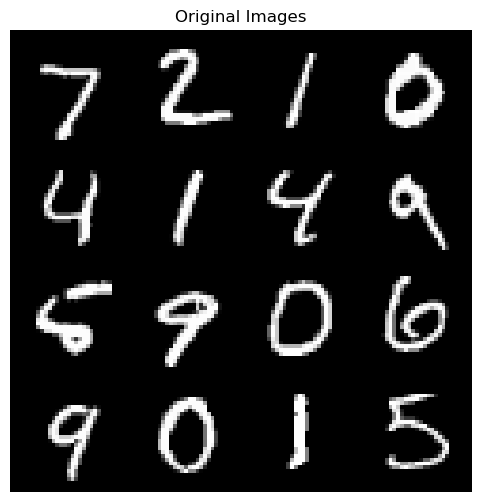

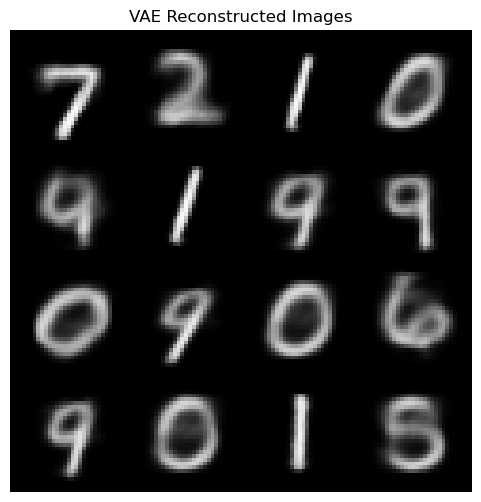

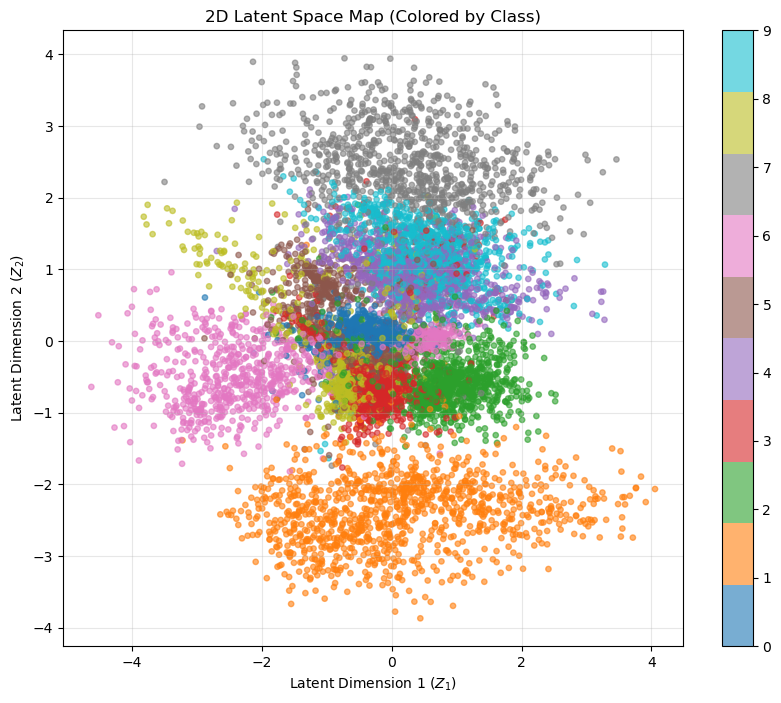

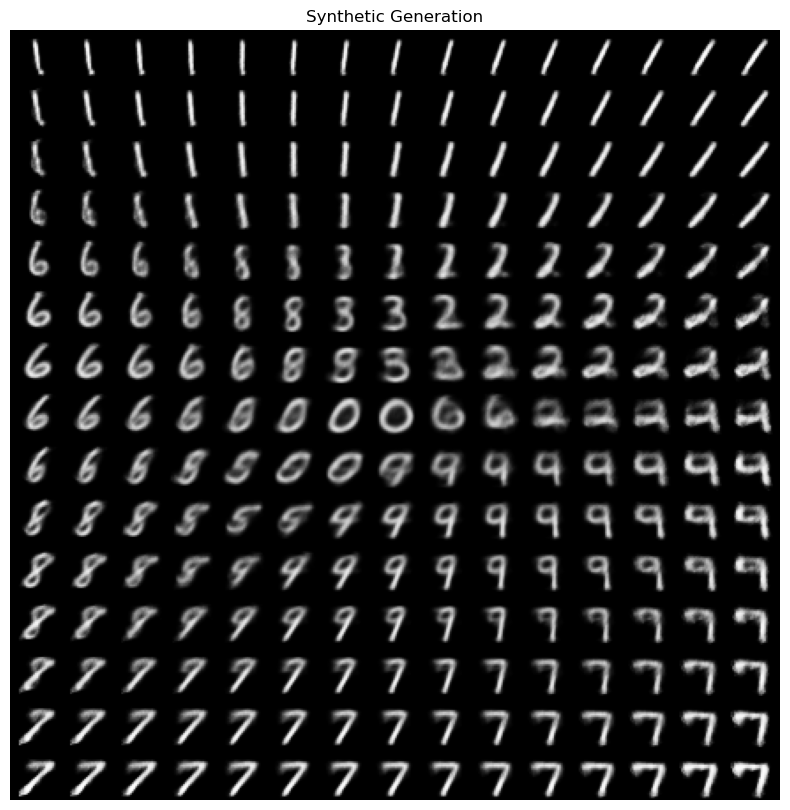

In [6]:
# Visualization

model.eval()

# Helper function to plot a grid of images
def show_image_grid(images, title):
    img_grid = make_grid(images[:16], nrow=4, padding=2, normalize=False).cpu()
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(img_grid.numpy(), (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

with torch.no_grad():
    # Plot 1: Reconstructions
    # Take a single batch from the test set
    data, labels = next(iter(test_loader))
    data = data.to(device)
    recon_data, mu, _ = model(data)
    
    # Reshape back to 28x28 images
    recon_images = recon_data.view(-1, 1, 28, 28)
    original_images = data.view(-1, 1, 28, 28)
    
    show_image_grid(original_images, "Original Images")
    show_image_grid(recon_images, "VAE Reconstructed Images")

    # Plot 2: Latent Space Scatter
    # Process the entire test set to get their latent coordinates (mu)
    latent_coords = []
    latent_labels = []
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        latent_coords.append(mu.cpu().numpy())
        latent_labels.append(labels.numpy())
        
    latent_coords = np.concatenate(latent_coords, axis=0)
    latent_labels = np.concatenate(latent_labels, axis=0)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_coords[:, 0], latent_coords[:, 1], c=latent_labels, cmap='tab10', alpha=0.6, s=15)
    plt.colorbar(scatter, ticks=range(10))
    plt.title("2D Latent Space Map (Colored by Class)")
    plt.xlabel("Latent Dimension 1 ($Z_1$)")
    plt.ylabel("Latent Dimension 2 ($Z_2$)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot 3: Generative Sampling
    n = 15  # 15x15 grid of synthetic images
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    synthetic_images = []

    # Walk through the coordinates of 2D Gaussian prior
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # Formulate the latent coordinate vector z
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            # Pass through the decoder and explicitly shape as (1, Height, Width)
            decoded = model.decode(z).view(1, 28, 28)
            synthetic_images.append(decoded)
            
    synthetic_tensor = torch.stack(synthetic_images, dim=0)
    img_grid = make_grid(synthetic_tensor, nrow=n, padding=1).cpu()
    
    grid_np = img_grid[0].numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(grid_np, cmap='gray')
    plt.title("Synthetic Generation")
    plt.axis('off')
    plt.show()

#### FashinMNIST Example

In [7]:
# Configuration & Hyperparameters
# Optimized for CPU execution
device = torch.device("cpu")

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 1e-3
Z_DIM = 2            # 2D latent space
HIDDEN_DIM = 400
INPUT_DIM = 784      # 28x28 pixel images

In [8]:
model = VAE(INPUT_DIM, HIDDEN_DIM, Z_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Data Loading
transform = transforms.ToTensor()
dataset_class = datasets.FashionMNIST
dataset_name = "FashionMNIST"

train_dataset = dataset_class(root='./data', train=True, transform=transform, download=True)
test_dataset = dataset_class(root='./data', train=False, transform=transform, download=False)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Successfully loaded {dataset_name}.")

Successfully loaded FashionMNIST.


In [9]:
# Training Loop
print("Start training VAE...")
model.train()
for epoch in range(1, EPOCHS + 1):
    train_loss = 0
    train_bce = 0
    train_kld = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        train_bce += bce.item()
        train_kld += kld.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_bce = train_bce / len(train_loader.dataset)
    avg_kld = train_kld / len(train_loader.dataset)
    
    print(f"Epoch [{epoch}/{EPOCHS}]  | Total Loss: {avg_loss:.2f} | Recon Error: {avg_bce:.2f} | KL Penalty: {avg_kld:.2f}")

print("Training Complete!")

Start training VAE...
Epoch [1/25]  | Total Loss: 290.43 | Recon Error: 283.48 | KL Penalty: 6.95
Epoch [2/25]  | Total Loss: 272.59 | Recon Error: 266.11 | KL Penalty: 6.47
Epoch [3/25]  | Total Loss: 269.42 | Recon Error: 263.02 | KL Penalty: 6.40
Epoch [4/25]  | Total Loss: 267.57 | Recon Error: 261.17 | KL Penalty: 6.39
Epoch [5/25]  | Total Loss: 266.25 | Recon Error: 259.86 | KL Penalty: 6.39
Epoch [6/25]  | Total Loss: 265.37 | Recon Error: 258.99 | KL Penalty: 6.38
Epoch [7/25]  | Total Loss: 264.68 | Recon Error: 258.30 | KL Penalty: 6.38
Epoch [8/25]  | Total Loss: 264.15 | Recon Error: 257.78 | KL Penalty: 6.37
Epoch [9/25]  | Total Loss: 263.76 | Recon Error: 257.40 | KL Penalty: 6.36
Epoch [10/25]  | Total Loss: 263.32 | Recon Error: 256.94 | KL Penalty: 6.38
Epoch [11/25]  | Total Loss: 263.04 | Recon Error: 256.66 | KL Penalty: 6.38
Epoch [12/25]  | Total Loss: 262.68 | Recon Error: 256.30 | KL Penalty: 6.38
Epoch [13/25]  | Total Loss: 262.40 | Recon Error: 256.02 | KL 

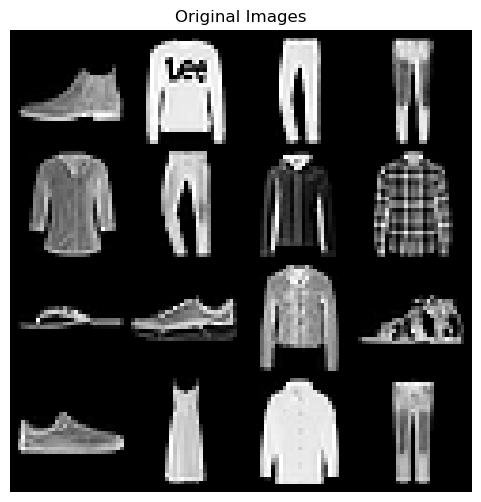

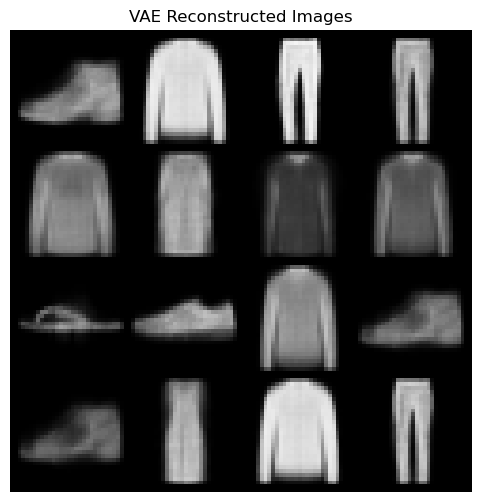

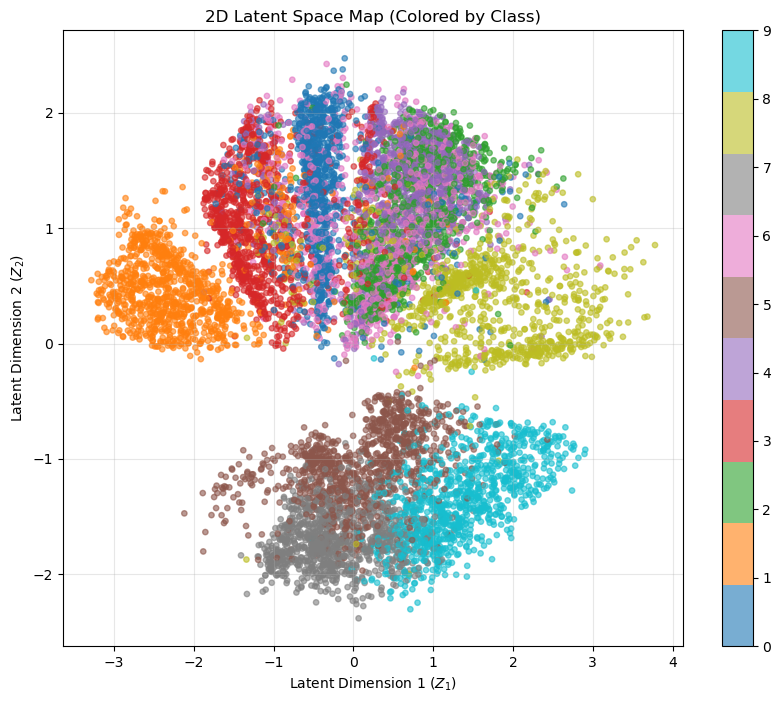

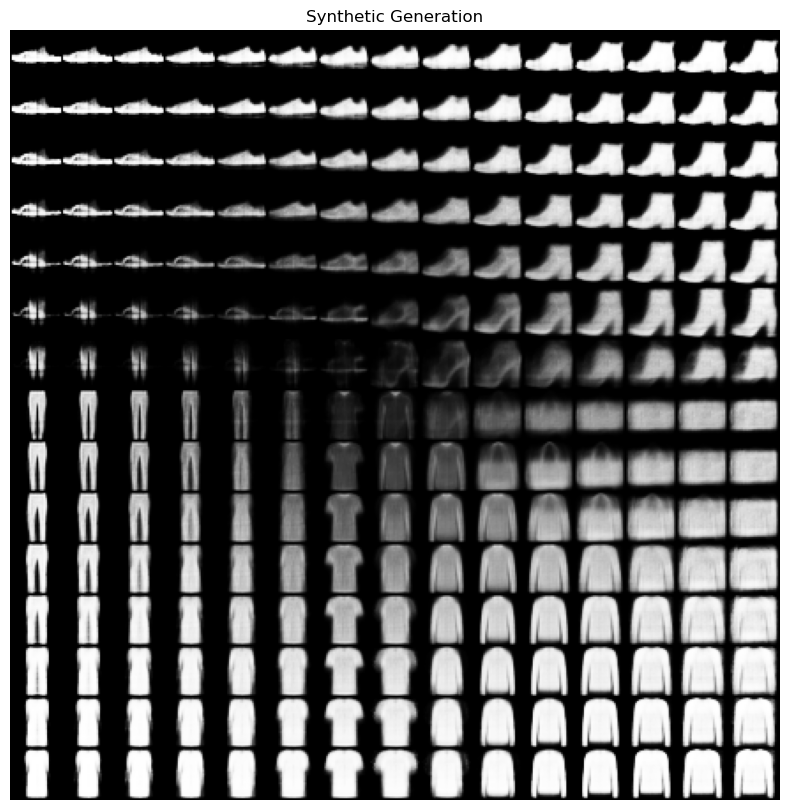

In [10]:
# Visualization

model.eval()

with torch.no_grad():
    # Plot 1: Reconstructions
    # Take a single batch from the test set
    data, labels = next(iter(test_loader))
    data = data.to(device)
    recon_data, mu, _ = model(data)
    
    # Reshape back to 28x28 images
    recon_images = recon_data.view(-1, 1, 28, 28)
    original_images = data.view(-1, 1, 28, 28)
    
    show_image_grid(original_images, "Original Images")
    show_image_grid(recon_images, "VAE Reconstructed Images")

    # Plot 2: Latent Space Scatter
    # Process the entire test set to get their latent coordinates (mu)
    latent_coords = []
    latent_labels = []
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        latent_coords.append(mu.cpu().numpy())
        latent_labels.append(labels.numpy())
        
    latent_coords = np.concatenate(latent_coords, axis=0)
    latent_labels = np.concatenate(latent_labels, axis=0)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_coords[:, 0], latent_coords[:, 1], c=latent_labels, cmap='tab10', alpha=0.6, s=15)
    plt.colorbar(scatter, ticks=range(10))
    plt.title("2D Latent Space Map (Colored by Class)")
    plt.xlabel("Latent Dimension 1 ($Z_1$)")
    plt.ylabel("Latent Dimension 2 ($Z_2$)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot 3: Generative Sampling
    n = 15  # 15x15 grid of synthetic images
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    synthetic_images = []

    # Walk through the coordinates of 2D Gaussian prior
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # Formulate the latent coordinate vector z
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            # Pass through the decoder and explicitly shape as (1, Height, Width)
            decoded = model.decode(z).view(1, 28, 28)
            synthetic_images.append(decoded)
            
    synthetic_tensor = torch.stack(synthetic_images, dim=0)
    img_grid = make_grid(synthetic_tensor, nrow=n, padding=1).cpu()
    
    grid_np = img_grid[0].numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(grid_np, cmap='gray')
    plt.title("Synthetic Generation")
    plt.axis('off')
    plt.show()